# Class Inspection Notebook

This notebook inspects one bbox-level CBIR item at a time.

Default workflow:

1. Choose a `target_class`
2. Choose a dataset `split`
3. Choose a 1-based `idx`
4. Render the original frame with the selected bbox highlighted
5. Render the padded crop derived from that bbox
6. Review the per-item report and crop dimensions in pixels

Color legend in the frame view:

- red: selected bbox
- orange: other bboxes of the same class in the frame
- gray: other object classes in the frame


In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import HTML, display
from PIL import Image, ImageDraw

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == "mvp" else cwd
MVP_ROOT = REPO_ROOT / "mvp"
if not MVP_ROOT.exists():
    raise RuntimeError(f"Could not locate the mvp directory from {cwd}")
if str(MVP_ROOT) not in sys.path:
    sys.path.insert(0, str(MVP_ROOT))

from data_prep import (  # noqa: E402
    DEFAULT_BENCHMARK_AREA_THRESHOLD,
    build_class_manifest,
    default_manifest_path,
    load_split_context,
    write_manifest,
)

target_class = "Traineira"
split = "train"
idx = 30
padding_ratio = 0.15
benchmark_only = True

In [9]:
manifest_path = default_manifest_path(target_class, REPO_ROOT)
records = build_class_manifest(
    target_class,
    padding_ratio=padding_ratio,
    benchmark_area_threshold=DEFAULT_BENCHMARK_AREA_THRESHOLD,
    repo_root=REPO_ROOT,
)
write_manifest(records, manifest_path)

selected_records = [
    record
    for record in records
    if record["split"] == split and (record["is_benchmark_candidate"] or not benchmark_only)
]
if not selected_records:
    raise ValueError(
        f"No records available for class={target_class!r}, split={split!r}, benchmark_only={benchmark_only!r}"
    )
if idx < 1 or idx > len(selected_records):
    raise IndexError(
        f"idx must be between 1 and {len(selected_records)} for the current selection; got {idx}"
    )

record = selected_records[idx - 1]
context = load_split_context(split, REPO_ROOT)
frame_annotations = context["annotations_by_image_id"][record["image_id"]]
frame_labels = sorted({annotation["label"] for annotation in frame_annotations})
same_class_instances = sum(1 for annotation in frame_annotations if annotation["label"] == target_class)

report_rows = [
    ("target_class", record["target_class"]),
    ("split", record["split"]),
    ("selection_idx", idx),
    ("manifest_idx_in_split", record["idx_in_class_split"]),
    ("image_filename", record["image_filename"]),
    ("image_path", record["image_path"]),
    ("camera_id", record["camera_id"]),
    ("timestamp", record["timestamp"]),
    ("bbox_xywh", f"({record['bbox_x']:.1f}, {record['bbox_y']:.1f}, {record['bbox_w']:.1f}, {record['bbox_h']:.1f})"),
    ("bbox_area", f"{record['bbox_area']:.1f}"),
    ("size_bucket", record["size_bucket"]),
    ("crop_xyxy", f"({record['crop_x1']}, {record['crop_y1']}, {record['crop_x2']}, {record['crop_y2']})"),
    ("crop_dimensions_px", f"{record['crop_w']} x {record['crop_h']}"),
    ("padding_ratio", f"{record['padding_ratio']:.2f}"),
    ("occluded", record["occluded"]),
    ("difficult", record["difficult"]),
    ("is_benchmark_candidate", record["is_benchmark_candidate"]),
    ("n_objects_in_frame", record["n_objects_in_frame"]),
    ("same_class_instances_in_frame", same_class_instances),
    ("other_labels_in_frame", ", ".join(record["other_labels_in_frame"]) or "-"),
    ("all_labels_in_frame", ", ".join(frame_labels)),
    ("selection_size", len(selected_records)),
    ("manifest_path", str(manifest_path)),
]

table_html = [
    "<table>",
    "<thead><tr><th>Field</th><th>Value</th></tr></thead>",
    "<tbody>",
]
for key, value in report_rows:
    table_html.append(f"<tr><td><code>{key}</code></td><td>{value}</td></tr>")
table_html.append("</tbody></table>")

display(HTML("".join(table_html)))


Field,Value
target_class,Traineira
split,train
selection_idx,30
manifest_idx_in_split,498
image_filename,CDG_PTZ1_1695491902566616000.jpg
image_path,/Users/gabriel/_pgms/personal/cbir/data/images_from_dataset/CDG_PTZ1_1695491902566616000.jpg
camera_id,CDG_PTZ1
timestamp,1695491902566616000
bbox_xywh,"(35.0, 351.0, 56.0, 20.0)"
bbox_area,1120.0


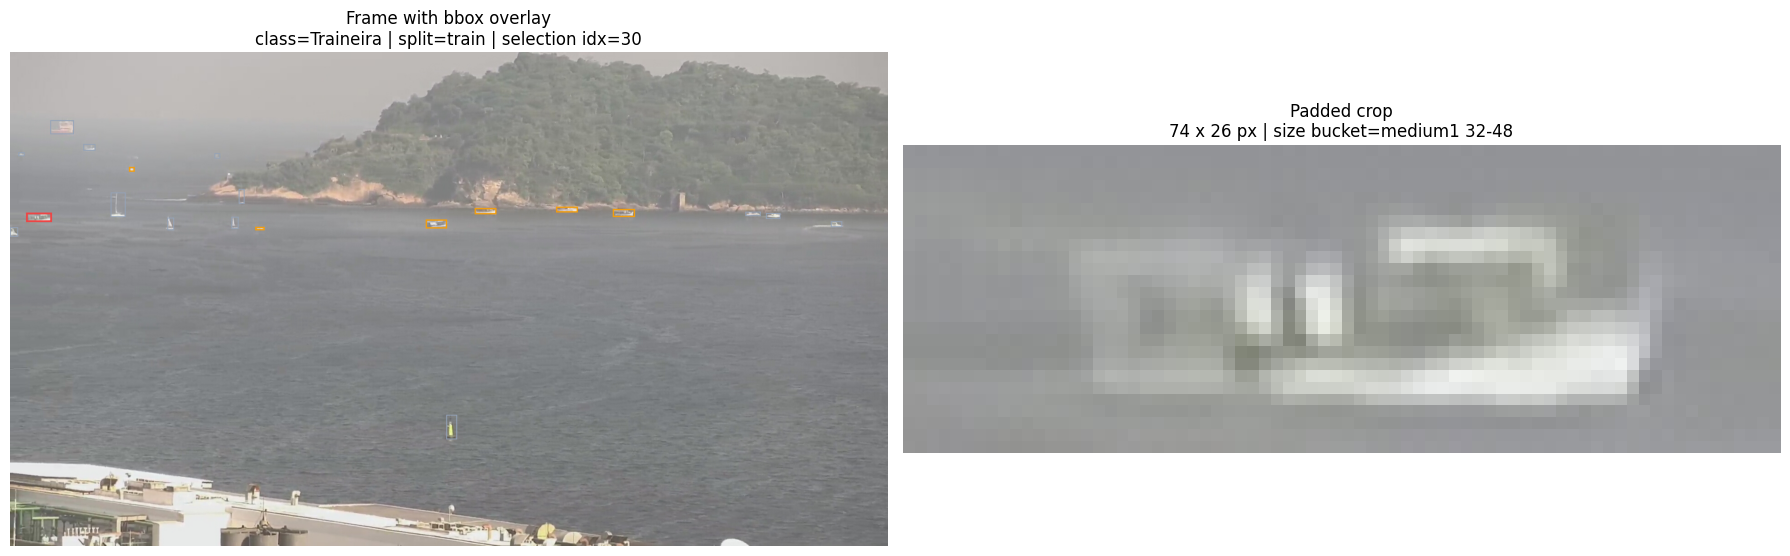

In [10]:
image = Image.open(record["image_path"]).convert("RGB")
overlay = image.copy()
draw = ImageDraw.Draw(overlay)

for annotation in frame_annotations:
    x, y, width, height = annotation["bbox"]
    x1 = x
    y1 = y
    x2 = x + width
    y2 = y + height
    if annotation["id"] == record["annotation_id"]:
        outline = "#ef4444"
        line_width = 4
    elif annotation["label"] == target_class:
        outline = "#f59e0b"
        line_width = 3
    else:
        outline = "#94a3b8"
        line_width = 2
    draw.rectangle((x1, y1, x2, y2), outline=outline, width=line_width)

crop = image.crop((record["crop_x1"], record["crop_y1"], record["crop_x2"], record["crop_y2"]))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(overlay)
axes[0].set_title(
    f"Frame with bbox overlay\nclass={target_class} | split={split} | selection idx={idx}"
)
axes[0].axis("off")

axes[1].imshow(crop)
axes[1].set_title(
    f"Padded crop\n{record['crop_w']} x {record['crop_h']} px | size bucket={record['size_bucket']}"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()


## Notes for expansion

This notebook is intentionally minimal for the first qualitative pass.

Planned extensions:

- browsing previous and next examples
- class-level grids of examples
- side-by-side comparison between strong classes
- optional crop caching to disk
- direct handoff to embedding extraction and Milvus indexing
